In [78]:
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

with h5py.File("alldata.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

import scipy.spatial

nsamples = dat["trap_centers"].shape[0]
dat["rij"] = np.zeros(
    (
        dat["trap_centers"].shape[0],
        dat["trap_centers"].shape[1],
        dat["trap_centers"].shape[1],
    )
)
# dat["rx_ij"] = np.zeros(
#     (
#         dat["trap_centers"].shape[0],
#         dat["trap_centers"].shape[1],
#         dat["trap_centers"].shape[1],
#     )
# )
# dat["ry_ij"] = np.zeros(
#     (
#         dat["trap_centers"].shape[0],
#         dat["trap_centers"].shape[1],
#         dat["trap_centers"].shape[1],
#     )
# )

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)

mask = dat["total_cost_func"] < 10  # Filter bad samples

In [83]:
np.sum(mask)

241

Only 1/4 samples are good samples.

### U_i vs V_off

Text(0, 0.5, 'U')

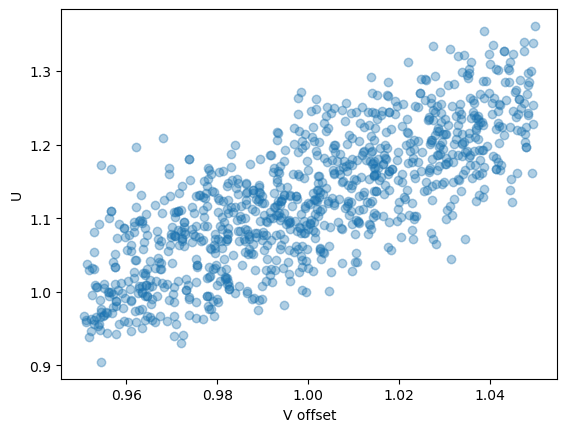

In [95]:
plt.scatter(dat["V_offset"][mask].flatten(), dat["U_i"][mask].flatten(), alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

Text(0, 0.5, 'U')

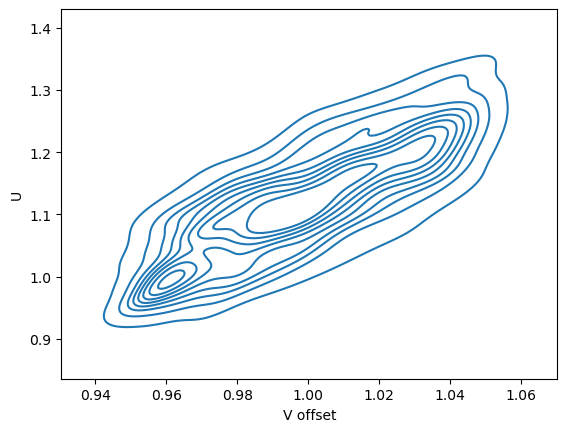

In [58]:
sns.kdeplot(x=dat["V_offset"][mask].flatten(), y=dat["U_i"][mask].flatten())
plt.xlabel("V offset")
plt.ylabel("U")

### t_ij

Set rij as the distance between the ith and jth points in the dataset.

(-0.05, 0.7)

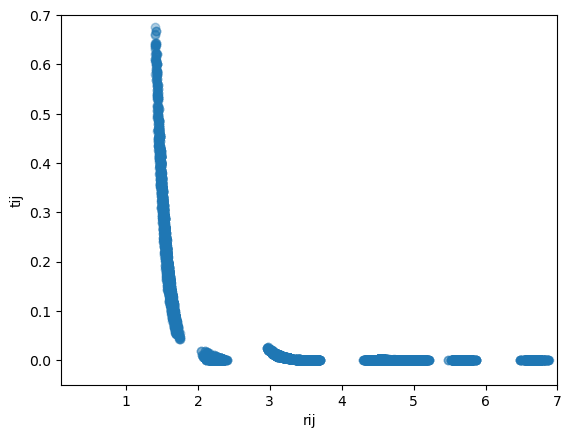

In [96]:
plt.scatter(dat["rij"][mask].flatten(), dat["t_ij"][mask].flatten(), alpha=0.1)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(0.1, 7)
plt.ylim(-0.05, 0.7)

In [39]:
np.linalg.norm([1.55, 1.6])

2.2276669409945464

rij = 0 → j = i

rij ~ 2.4 → j = (ix + 1, iy + 1)

(-0.05, 0.5)

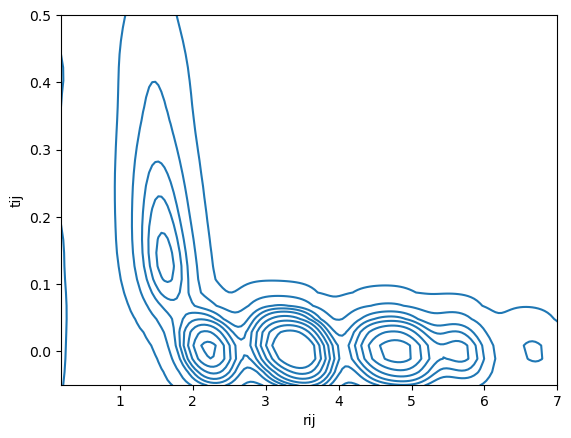

In [84]:
sns.kdeplot(x=dat["rij"][mask].flatten(), y=dat["t_ij"][mask].flatten())
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(0.2, 7)
plt.ylim(-0.05, 0.50)

Not only the relative distance, but the location in the lattice is also important.

(-0.05, 0.7)

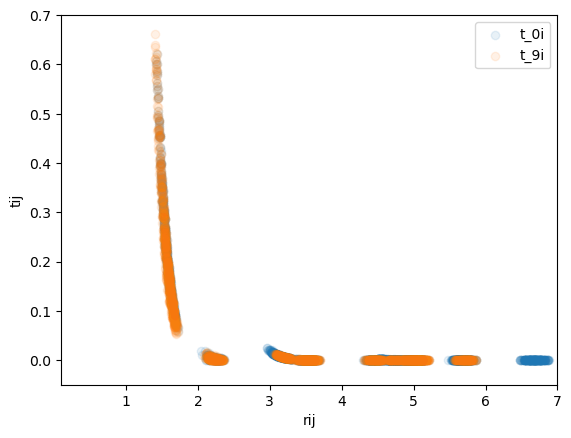

In [97]:
plt.scatter(
    dat["rij"][mask, 0, :].flatten(),
    dat["t_ij"][mask, 0, :].flatten(),
    alpha=0.1,
    label="t_0i",
)
plt.scatter(
    dat["rij"][mask, 8, 1:].flatten(),
    dat["t_ij"][mask, 8, 1:].flatten(),
    alpha=0.1,
    label="t_9i",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(0.1, 7)
plt.ylim(-0.05, 0.7)

The above statement is not true. The tunnelings are mostly relevant to the relative distance.

### V_i

(array([ 156.,  626., 1522., 2213., 2807., 2830., 2598., 2029., 1079.,
         140.]),
 array([-3.06944054, -2.48013748, -1.89083442, -1.30153136, -0.7122283 ,
        -0.12292524,  0.46637782,  1.05568088,  1.64498394,  2.234287  ,
         2.82359006]),
 <BarContainer object of 10 artists>)

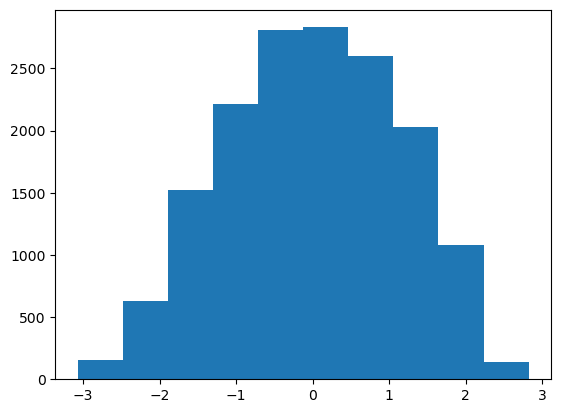

In [67]:
plt.hist(dat["t_ij"].diagonal(axis1=1, axis2=2).flatten())

(-0.05, 0.7)

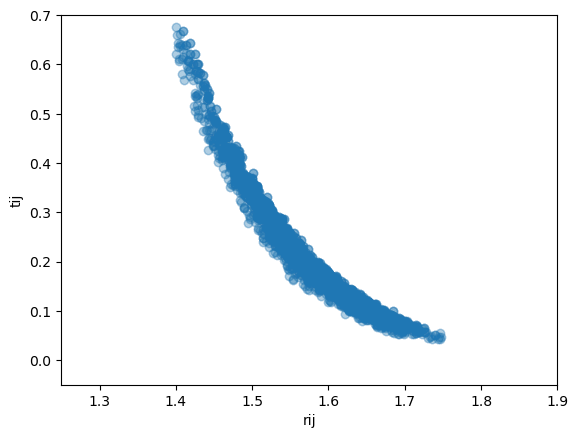

In [91]:
smallr = dat["rij"][mask].flatten() < 1.9

plt.scatter(
    x=dat["rij"][mask].flatten()[smallr],
    y=dat["t_ij"][mask].flatten()[smallr],
    alpha=0.1,
)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(1.25, 1.9)
plt.ylim(-0.05, 0.7)

(0.05, 0.7)

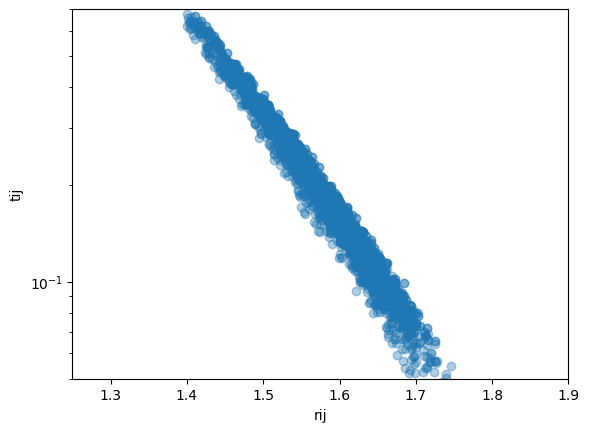

In [82]:
smallr = dat["rij"][mask].flatten() < 1.9

plt.scatter(
    x=dat["rij"][mask].flatten()[smallr],
    y=dat["t_ij"][mask].flatten()[smallr],
    alpha=0.1,
)
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")
plt.xlim(1.25, 1.9)
plt.ylim(0.05, 0.7)

Exponential decay.

(-0.05, 0.7)

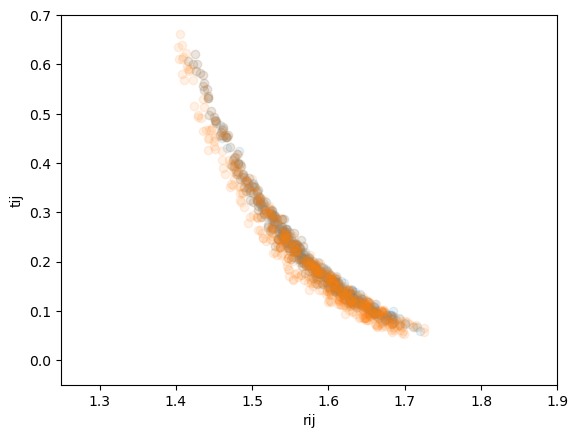

In [94]:
smallr = dat["rij"][mask, 0, :].flatten() < 1.9
plt.scatter(
    x=dat["rij"][mask, 0, :].flatten()[smallr],
    y=dat["t_ij"][mask, 0, :].flatten()[smallr],
    alpha=0.1,
)

smallr = dat["rij"][mask, 8, 1:].flatten() < 1.9
plt.scatter(
    x=dat["rij"][mask, 8, 1:].flatten()[smallr],
    y=dat["t_ij"][mask, 8, 1:].flatten()[smallr],
    alpha=0.1,
)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(1.25, 1.9)
plt.ylim(-0.05, 0.7)

### Analyze abnormal dp

(array([923.,  48.,  16.,   2.,   3.,   5.,   2.,   0.,   0.,   1.]),
 array([5.59965378e-06, 1.92113284e-01, 3.84220969e-01, 5.76328653e-01,
        7.68436338e-01, 9.60544022e-01, 1.15265171e+00, 1.34475939e+00,
        1.53686708e+00, 1.72897476e+00, 1.92108244e+00]),
 <BarContainer object of 10 artists>)

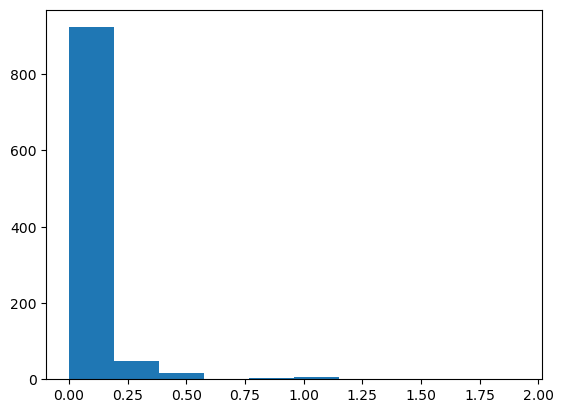

In [40]:
plt.hist(dat["t_ij"][:, 0, 5])

In [42]:
np.where(dat["t_ij"][:, 0, 5] > 1.5)

(array([545]),)

In [43]:
 dat["trap_centers"][545]

array([[-2.35134001, -2.35041483],
       [-2.30821494, -0.77222494],
       [-2.30821494,  0.77222494],
       [-2.35134001,  2.35041483],
       [-0.73808638, -2.47069622],
       [-0.75538482, -0.80011756],
       [-0.75538482,  0.80011756],
       [-0.73808638,  2.47069622],
       [ 0.73808638, -2.47069622],
       [ 0.75538482, -0.80011756],
       [ 0.75538482,  0.80011756],
       [ 0.73808638,  2.47069622],
       [ 2.35134001, -2.35041483],
       [ 2.30821494, -0.77222494],
       [ 2.30821494,  0.77222494],
       [ 2.35134001,  2.35041483]])

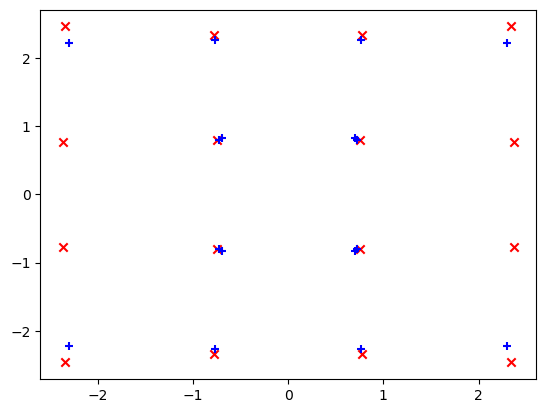

In [101]:
id = 0
plt.scatter(
    dat["trap_centers"][id, :, 0], dat["trap_centers"][id, :, 1], c="r", marker="x"
)
plt.scatter(dat["wf_centers"][id, :, 0], dat["wf_centers"][id, :, 1], c="b", marker="+")

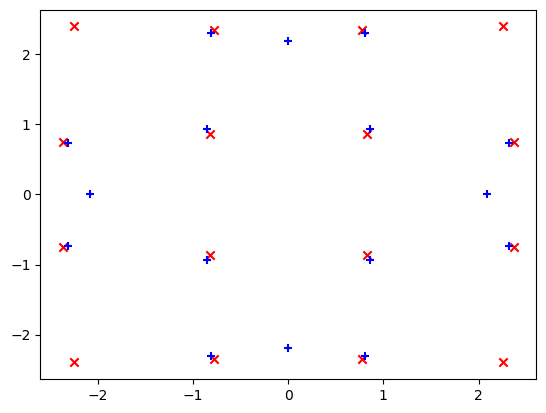

In [100]:
id = 14
plt.scatter(
    dat["trap_centers"][id, :, 0], dat["trap_centers"][id, :, 1], c="r", marker="x"
)
plt.scatter(dat["wf_centers"][id, :, 0], dat["wf_centers"][id, :, 1], c="b", marker="+")

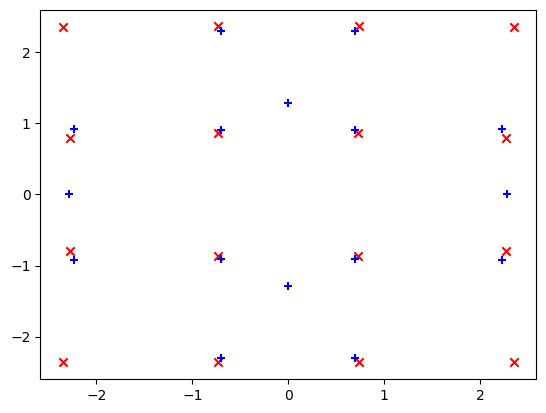

In [99]:
id = 545
plt.scatter(
    dat["trap_centers"][id, :, 0], dat["trap_centers"][id, :, 1], c="r", marker="x"
)
plt.scatter(dat["wf_centers"][id, :, 0], dat["wf_centers"][id, :, 1], c="b", marker="+")

Conclusion: save `wf_centers` and `total_cost_func` to rule out bad samples.